# SVR
Notebook separado para validacao e visualizacao de SVR.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import KFold
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error

try:
    from spatial_metrics import ide_isi_from_prediction_points
except ModuleNotFoundError:
    from src.spatial_metrics import ide_isi_from_prediction_points

altitude = []
data_folder = "../data/"
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_07_43.980Z.csv"))
altitude.append(pd.read_csv(data_folder + "Altitude_2025-10-14T20_15_03.183Z.csv"))


In [ ]:
def discretize_by_percentile(values, n_divisions=3):
    if n_divisions <= 0:
        raise ValueError("n_divisions deve ser maior que zero.")
    arr = np.asarray(np.ma.filled(values, np.nan), dtype=float)
    flat = arr.reshape(-1)
    valid_mask = np.isfinite(flat)
    if valid_mask.sum() == 0:
        return np.full(arr.shape, np.nan)
    valid_values = flat[valid_mask]
    quantiles = np.linspace(0, 1, int(n_divisions) + 1)
    edges = np.nanquantile(valid_values, quantiles)
    edges = np.unique(edges)
    classes_flat = np.full(flat.shape, np.nan)
    if len(edges) <= 1:
        classes_flat[valid_mask] = 1
    else:
        bins = np.digitize(valid_values, edges[1:-1], right=True) + 1
        classes_flat[valid_mask] = bins.astype(float)
    return classes_flat.reshape(arr.shape)


In [ ]:
def create_grid(data: pd.DataFrame, resolution: float, model, n_divisions: int = 3):
    x = data.iloc[:, 0].to_numpy()
    y = data.iloc[:, 1].to_numpy()
    min_x, max_x = x.min(), x.max()
    min_y, max_y = y.min(), y.max()
    grid_x = np.arange(min_x, max_x + 1e-8, resolution)
    grid_y = np.arange(min_y, max_y + 1e-8, resolution)
    preds = []
    for xi in grid_x:
        batch = pd.DataFrame({"x": np.full(grid_y.shape, xi), "y": grid_y})
        y_pred = model.predict(batch)
        y_pred = np.asarray(y_pred).reshape(-1)
        for yi, zi in zip(grid_y, y_pred):
            preds.append([xi, yi, float(zi)])
    predict_df = pd.DataFrame(preds, columns=["x", "y", "z"])
    grid_data = predict_df.pivot(index="y", columns="x", values="z")
    grid_disc = discretize_by_percentile(grid_data.to_numpy(), n_divisions=n_divisions)
    n_classes = int(np.nanmax(grid_disc)) if np.isfinite(grid_disc).any() else 1
    cmap = sns.color_palette("viridis", n_colors=max(n_classes, 1))
    plt.figure(figsize=(8, 6))
    sns.heatmap(grid_disc, cmap=cmap, vmin=1, vmax=max(n_classes, 1), cbar_kws={"label": "Classe (percentil)"})
    plt.title(f"Mapa discretizado da previsao do SVR ({n_divisions} divisoes)")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.tight_layout()
    plt.show()
    return predict_df


In [ ]:
def cross_validate_svr(data: pd.DataFrame, n_splits=5):
    x, z = data.iloc[:, :-1], data.iloc[:, 2]
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_scores = []
    results = []
    for kernel in ["linear", "rbf", "poly"]:
        for train_index, test_index in kf.split(x):
            x_train, x_test = x.iloc[train_index], x.iloc[test_index]
            z_train, z_test = z.iloc[train_index], z.iloc[test_index]
            model = SVR(kernel=kernel)
            model.fit(x_train, z_train)
            z_pred = model.predict(x_test)
            mae = mean_absolute_error(z_test, z_pred)
            mae_scores.append(mae)
        average_mae = float(np.mean(mae_scores))
        model = SVR(kernel=kernel)
        model.fit(x, z)
        grid_predictions = create_grid(data, 0.0001, model)
        ide_isi_info = ide_isi_from_prediction_points(grid_predictions)
        results.append({
            "modelo": "svr",
            "kernel": kernel,
            "mae_medio": average_mae,
            "ide": ide_isi_info["ide"],
            "isi": ide_isi_info["isi"],
            "ise": ide_isi_info["ise"],
            "classe_isi": ide_isi_info["classe_isi"],
            "nugget": ide_isi_info["nugget"],
            "structured_variance": ide_isi_info["structured_variance"],
        })
        print(
            f"SVR with {kernel} kernel - Average MAE: {average_mae:.4f} - "
            f"IDE: {ide_isi_info['ide']:.2f}% - ISI/ISE: {ide_isi_info['isi']:.2f}% "
            f"({ide_isi_info['classe_isi']})"
        )
        mae_scores.clear()
    results_df = pd.DataFrame(results)
    output_path = Path("../models/svr_metrics.csv")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_path, index=False)
    display(results_df)
    return results_df


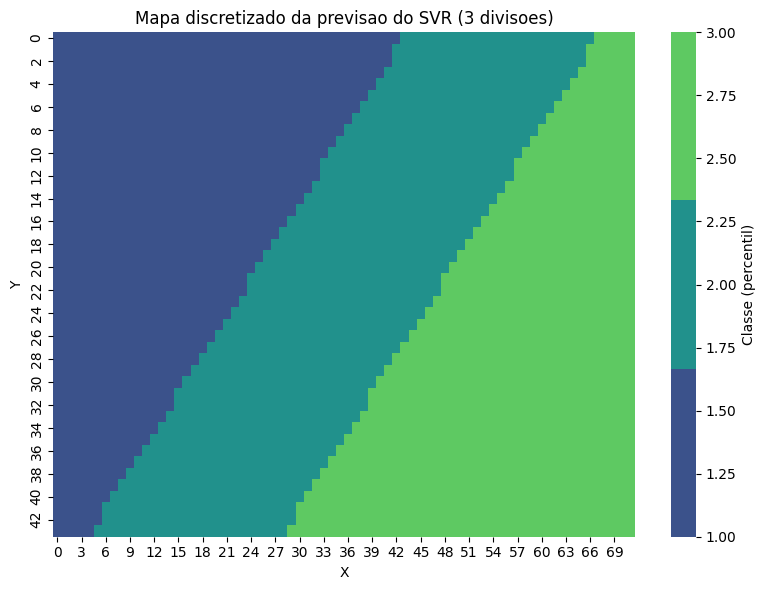

SVR with linear kernel - Average MAE: 4.9884 - IDE: 98.11% - ISI/ISE: 1.89% (forte)


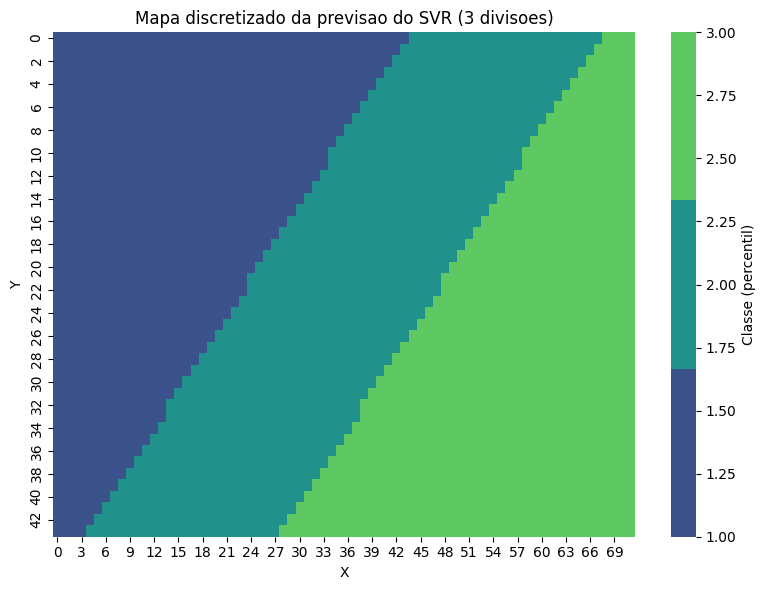

SVR with rbf kernel - Average MAE: 4.9907 - IDE: 97.22% - ISI/ISE: 2.78% (forte)


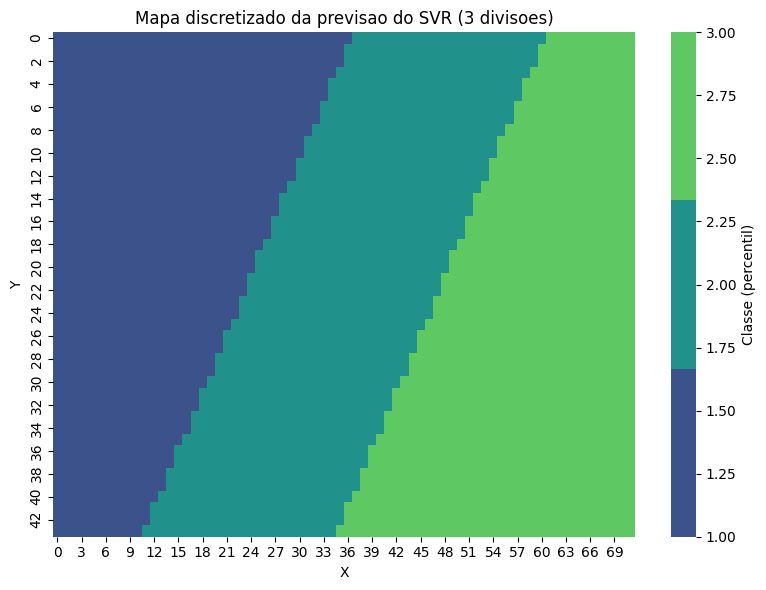

SVR with poly kernel - Average MAE: 4.9874 - IDE: 98.50% - ISI/ISE: 1.50% (forte)


,modelo,kernel,mae_medio,ide,isi,ise,classe_isi,nugget,structured_variance
0,svr,linear,4.988378,98.111988,1.888012,1.888012,forte,1.789685e-06,9.300237e-05
1,svr,rbf,4.990652,97.215073,2.784927,2.784927,forte,1.000000e-10,3.490759e-09
2,svr,poly,4.987389,98.501509,1.498491,1.498491,forte,4.247049e-06,2.791746e-04


In [ ]:
svr_results = cross_validate_svr(altitude[0])
